In [1]:
import numpy as np
import matplotlib.pyplot as plt
import vectorHASH_functions

## Test out layers

### Run scaffold dynamics

In [ ]:
def scaffold_dynamics(h_init, W_gh, W_hg, lambdas, Niter, theta=0.5):
    """
    Runs scaffold dynamics: hc-grid loop
    h_init: initial hc activations

    Returns final hc activations and corresponding grid states (should be fixed points)
    """
    h = h_init.copy()

    for _ in range(Niter):
        g = grid_CAN(W_gh @ h, lambdas)
        h = relu(W_hg @ g - theta)

    return h, g

def noisy_hc(hc, noise):
    """
    Adds gaussian (0,1) noise to hc state.
    noise: scaling parameter
    """
    
    noisy = hc + noise * np.random.randn(*hc.shape)
    return noisy


In [ ]:
# define parameters
lams = np.array([3, 4, 5])          # grid periods
Ng = np.sum(lams*lams)              # number of grid units
patts_total = np.prod(lams*lams)    # total number of patterns possible to store
Nh = 400                            # number of hc units

g, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
print(g.shape)   #(Ng, patts_total)
print(hc.shape)   #(Nh, patts_total)
print(W_gh.shape)   #(Ng, Nh)
print(W_hg.shape)   #(Nh, Ng)

# run on a stored pattern
h = hc
h_step, _ = scaffold_dynamics(h, W_gh, W_hg, lams, Niter=1)
print(np.allclose(h_step, h)) #allclose is for equality within some tolerance

# run on a noisy pattern
noisy = noisy_hc(h, 0.2)
h_step, _ = scaffold_dynamics(h, W_gh, W_hg, lams, Niter=1)
print(np.allclose(h_step, h))

(50, 3600)
(400, 3600)
(50, 400)
(400, 50)
True
True


### Set up sensory layers

In [ ]:
Ns = patts_total  # number of sensory units
sens = get_random_patterns(200, Ns)   # random binary patterns
W_hs, W_sh = sensory_weights(sens, hc)  # gets weights
print(W_hs.shape, W_sh.shape)

### Run recall

In [ ]:
s_rec = recall(sens, W_hs, W_sh, W_gh, W_hg, lams, Niter=1)
print(get_overlap(sens, s_rec)) # overlap of 1 implies perfect recall - there is no noise so this is expected

## Memory Continuum

In [ ]:
# define parameters
lams = np.array([3, 4, 5])
Ng = np.sum(lams*lams)
patts_total = np.prod(lams*lams)
Nh = 400
Ns = patts_total

# set up scaffold and patterns
g, W_hg, hc, W_gh = scaffold_layers(Ng, Nh, patts_total, lams, 0)
sens_patterns = np.sign(np.random.randn(Ns, patts_total))

pattern_range = np.arange(1, patts_total+1, 100)  # list of Npatts to test memory on
plot_list = []

for N_patts in pattern_range:

    # have to restrict sensory layer to the number we want to test recall on
    sens = sens_patterns[:, :N_patts]
    W_hs, W_sh = sensory_weights(sens, hc)

    #perfect cues (no noise)
    s_recalled = recall(sens, W_hs, W_sh, W_gh, W_hg, lams, Niter=5)

    #plot overlap
    #overlap = np.mean(get_overlap(s_recalled, sens))
    #plot_list.append(overlap)

    #to plot mutual information
    mutual_info = np.mean(get_mutual_info(s_recalled, sens))
    plot_list.append(mutual_info)

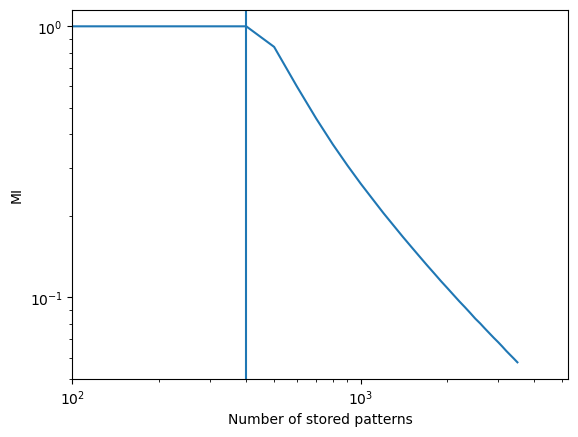

In [97]:
plt.plot(pattern_range, plot_list)
plt.xscale('log')
plt.yscale('log')
plt.xlim(xmin=100)
plt.xlabel("Number of stored patterns")
plt.ylabel("MI")
plt.axvline(Nh)
plt.show()

## Test generalization properties

In [91]:
def test_generalization(grid, W_hg, hc, lambdas, Npatts_list, theta=0.5, pflip=0, Niter=5):

    Nh = W_hg.shape[0]
    num_fp = []

    for Npatts in Npatts_list:
        hc_concat = hc[:, :Npatts] + np.random.normal(0, pflip, (Nh, Npatts))
        W_gh = (1/Npatts) * grid[:, :Npatts] @ hc_concat.T

        # test all patterns regardless of how many trained
        h_init = relu(W_hg @ grid - theta)
        h, _ = scaffold_dynamics(h_init, W_gh, W_hg, lambdas, Niter, theta)

        errors = np.linalg.norm(h - hc, axis=0) / Nh
        num_fp.append(np.sum(errors < 0.003))
    
    return num_fp

lams = np.array([3, 4, 5])
Ng = np.sum(lams*lams)
patts_total = np.prod(lams*lams)
Nh = 400
Ns = patts_total

g, W_hg, hc, _ = scaffold_layers(Ng, Nh, patts_total, lams, gamma=0)

Npatts_list = np.arange(1, patts_total+1,100)
fps = test_generalization(g, W_hg, hc, lams, Npatts_list)

perm = np.random.permutation(patts_total)
fps_shuffled = test_generalization(g[:, perm], W_hg, hc[:, perm], lams, Npatts_list)

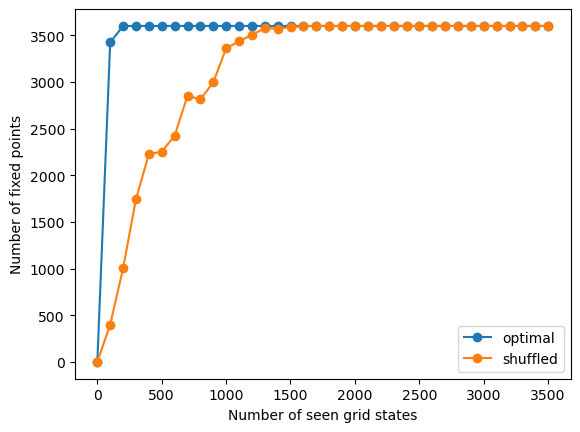

In [95]:
plt.plot(Npatts_list, fps, marker='o', linestyle='-', label="optimal")
plt.plot(Npatts_list, fps_shuffled, marker='o', linestyle='-', label='shuffled')
plt.xlabel("Number of seen grid states")
plt.ylabel("Number of fixed points")
plt.legend()
plt.show()